# Insurance Charge Prediction — Model 2: Random Forest
**Comparison with Model 1 (Linear Regression)**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')

df['sex'] = df['sex'].map({'female': 1, 'male': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Shape:", df.shape)
df.head()

Shape: (1338, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


## Add Interaction Feature (smoker × bmi)
**Why?** Smokers with high BMI have disproportionately high charges. Linear Regression missed this — Random Forest will capture it, but adding it explicitly helps both models.

In [4]:
df['smoker_bmi'] = df['smoker'] * df['bmi']

print("New feature added: smoker_bmi")
print("\nSample (only smokers):")
df[df['smoker'] == 1][['smoker', 'bmi', 'smoker_bmi', 'charges']].head(5)

New feature added: smoker_bmi

Sample (only smokers):


,smoker,bmi,smoker_bmi,charges
0,1,27.90,27.90,16884.9240
11,1,26.29,26.29,27808.7251
14,1,42.13,42.13,39611.7577
19,1,35.30,35.30,36837.4670
23,1,31.92,31.92,37701.8768


## Train / Test Split

In [5]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Features   : {list(X.columns)}")

Train size : (1070, 9)
Test size  : (268, 9)
Features   : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi']


## Train Random Forest

In [16]:
rf = RandomForestRegressor(
    n_estimators=100,   # 100 decision trees
    max_depth=10,     # trees grow fully
    min_samples_leaf=4,
    random_state=42
)

rf.fit(X_train, y_train)
print("Model trained!")

Model trained!


## Evaluate: R², MAE, RMSE

In [17]:
y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test,  y_pred_test)
mae      = mean_absolute_error(y_test, y_pred_test)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))

n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

gap = r2_train - r2_test

print(f"{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 47)
print(f"{'R2 Score':<25} {r2_train:>10.4f} {r2_test:>10.4f}")
print(f"{'MAE':<25} {'—':>10} {mae:>10.0f}")
print(f"{'RMSE':<25} {'—':>10} {rmse:>10.0f}")
print()
print(f"R-squared:          {r2_test:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"\n📌 Train-Test Gap: {gap:.4f}")
if gap > 0.1:
    print("⚠️  Possible overfitting — gap is large")
else:
    print("✅ Model looks good!")

Metric                         Train       Test
-----------------------------------------------
R2 Score                      0.9089     0.8735
MAE                                —       2509
RMSE                               —       4431

R-squared:          0.8735
Adjusted R-squared: 0.8691

📌 Train-Test Gap: 0.0354
✅ Model looks good!


## Cross Validation (5-Fold)
**Why?** Confirms the R² score is stable across different splits — not just a lucky test set.

In [18]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("📌 5-Fold Cross Validation R² Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean R²  : {cv_scores.mean():.4f}")
print(f"  Std Dev  : {cv_scores.std():.4f}")
print("\n(Low std = model is stable across splits ✅)")

📌 5-Fold Cross Validation R² Scores:
  Fold 1: 0.8728
  Fold 2: 0.7968
  Fold 3: 0.8920
  Fold 4: 0.8398
  Fold 5: 0.8604

  Mean R²  : 0.8524
  Std Dev  : 0.0325

(Low std = model is stable across splits ✅)


## Feature Importance Plot

📌 Feature Importances (Random Forest):
         Feature  Importance
      smoker_bmi    0.821259
             age    0.122966
             bmi    0.027542
        children    0.011914
          smoker    0.007928
             sex    0.002504
region_southeast    0.002128
region_southwest    0.002048
region_northwest    0.001712


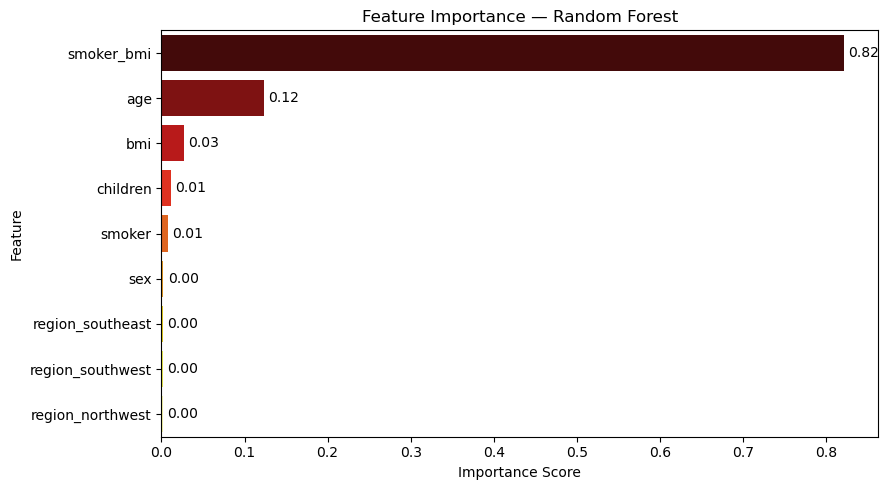

In [19]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("📌 Feature Importances (Random Forest):")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='hot')
for container in ax.containers: 
    ax.bar_label(container, fmt='%.2f', padding=3)
    
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Actual vs Predicted + Residual Distribution

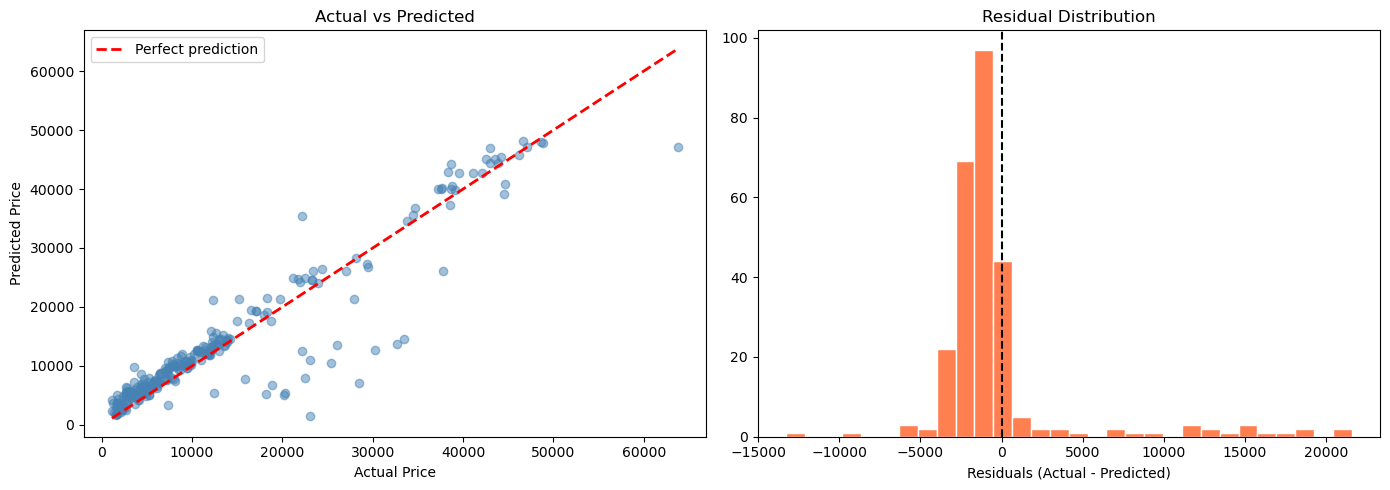

In [20]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Residual Distribution
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

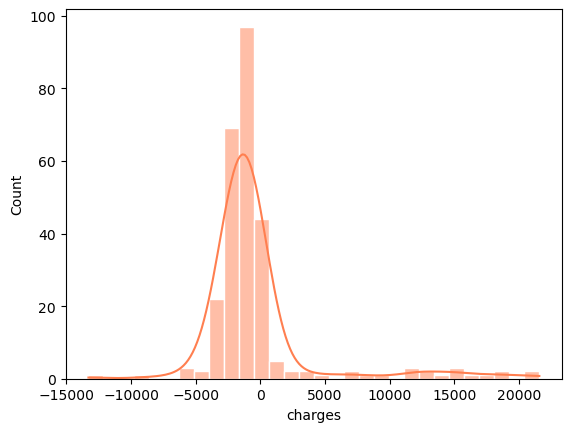

In [21]:
sns.histplot(residuals, bins=30, color='coral', edgecolor='white', kde=True)
plt.show()


## Model 1 vs Model 2 Comparison Table


In [22]:
# Linear Regression with smoker_bmi feature (updated Model 1)
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_r2   = r2_score(y_test, lr_pred)
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

comparison = pd.DataFrame({
    'Metric': ['R² Score', 'MAE ($)', 'RMSE ($)'],
    'Linear Regression (M1)': [round(lr_r2, 4), round(lr_mae, 0), round(lr_rmse, 0)],
    'Random Forest (M2)':     [round(r2_test, 4), round(mae, 0), round(rmse, 0)]
})

print("📊 Model Comparison: Linear Regression vs Random Forest")
print("=" * 58)
print(comparison.to_string(index=False))
print()
r2_improvement = (r2_test - lr_r2) * 100
mae_improvement = ((lr_mae - mae) / lr_mae) * 100
print(f"✅ R² improved by   : +{r2_improvement:.1f} points")
print(f"✅ MAE reduced by   : {mae_improvement:.1f}%")

📊 Model Comparison: Linear Regression vs Random Forest
  Metric  Linear Regression (M1)  Random Forest (M2)
R² Score                  0.8653              0.8735
 MAE ($)               2757.0000           2509.0000
RMSE ($)               4574.0000           4431.0000

✅ R² improved by   : +0.8 points
✅ MAE reduced by   : 9.0%


In [23]:
# Single prediction
input_data = {
    'age': 30,
    'sex': 1,              # 1 = female, 0 = male
    'bmi': 27.5,
    'children': 2,
    'smoker': 1,           # 1 = yes, 0 = no
    'region_northwest': 0,
    'region_southeast': 0,
    'region_southwest': 1,
    'smoker_bmi': 1 * 27.5  # smoker × bmi (calculate manually)
}

input_df = pd.DataFrame([input_data])
predicted_charge = rf.predict(input_df)

print(f"Predicted Insurance Charge: ${predicted_charge[0]:,.2f}")

Predicted Insurance Charge: $19,460.70
